# エージェント評価 — 実エンジンによる自己対戦検証

本ノートブックは `submission/main.py` のルールベースエージェントを、Kaggle公式の
`kaggle-environments==1.30.1` に同梱された **本物の対戦エンジン**（`kaggle_environments.make("cabt")`）
を使って実際に対戦させ、勝率を計測する。Kaggleへのログインやデータダウンロードは不要
（エンジン自体がpipパッケージに含まれているため）。

比較対象はエンジンが標準で提供する2つのベースラインエージェント：
- `random_agent`: 合法な選択肢からランダムに選ぶ
- `first_agent`: 常にリスト内の最初の選択肢を選ぶ（決定的）

先攻・後攻の非対称性を打ち消すため、対戦ごとにプレイヤーのスロット(0/1)を入れ替えている。

In [1]:
import importlib.util
import time
from kaggle_environments import make
from kaggle_environments.envs.cabt.cabt import random_agent, first_agent
import kaggle_environments.envs.cabt.cabt as cabtmod

spec = importlib.util.spec_from_file_location("submission_main", "../submission/main.py")
sub = importlib.util.module_from_spec(spec)
spec.loader.exec_module(sub)

print("card DB loaded:", len(sub.CARD_DB), "cards,", len(sub.ATTACK_DB), "attacks")
print("deck size:", len(sub.load_deck()))


def play_match(agent_a, deck_a, agent_b, deck_b, n_games):
    def wrap(agent, deck):
        def a(obs):
            return deck if obs["select"] is None else agent(obs)
        return a
    a = wrap(agent_a, deck_a)
    b = wrap(agent_b, deck_b)
    wins = losses = draws = crashes = 0
    steps = []
    for g in range(n_games):
        env = make("cabt")
        if g % 2 == 0:
            result = env.run([a, b]); slot = 0
        else:
            result = env.run([b, a]); slot = 1
        final = result[-1][slot]
        steps.append(len(result))
        if final["status"] != "DONE":
            crashes += 1
        r = final["reward"]
        if r is None:
            crashes += 1
        elif r > 0:
            wins += 1
        elif r < 0:
            losses += 1
        else:
            draws += 1
    return dict(wins=wins, losses=losses, draws=draws, crashes=crashes, n=n_games,
                avg_steps=sum(steps) / len(steps))


Warning! The implementation of 'quoridor' has known issues. Please see the games list on github or the code for details.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO: Successfully loaded OpenSpiel environments: 40.


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_amazons


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_ant_foraging_arena


[kaggle_environments.envs.open_spiel_env.open_spiel_env] INFO:    open_spiel_backgammon


...

18:31:48 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/meta/llama-3.1-70b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


18:31:48 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/openai/gpt-oss-20b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


18:31:48 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/openai/gpt-oss-120b not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


18:31:48 - LiteLLM:WARNING: utils.py:2705 - register_model: model=openai/qwen/qwen3-235b-a22b-instruct-2507 not in built-in cost map and no prefix/region variant matched; cache cost fields will default to 0. To track cache cost, add cache_creation_input_token_cost and cache_read_input_token_cost to model_info


Loading environment llm_20_questions failed: No module named 'kaggle_environments.envs.llm_20_questions.llm_20_questions'
Loading environment lux_ai_s2 failed: No module named 'kaggle_environments.envs.lux_ai_s2.lux_ai_s2'
card DB loaded: 1267 cards, 1556 attacks
deck size: 60


## 1. デッキ選定：5つの候補をA/Bテストする

自作の2案（無色コストだけの"Kangaskhan swarm"／進化ラインの"Grimmsnarl ex"）、
`kaggle-environments` 同梱のサンプルデッキ（Kyogre + Snover→Mega Abomasnow ex の水タイプ
進化デッキ）、そのエネルギー比率を下げた変種（"lean"）、そして実戦リプレイ解析の結果
カードプール全体から選び直した現在の提出デッキ（Riolu→Mega Lucario ex の闘タイプ）を、
**同一のエージェント方策**（本エージェントの `agent`）で対戦させ、デッキそのものの強さを比較する。

（Mega Abomasnow ex水デッキを一度採用してから Mega Lucario ex闘デッキに乗り換えた経緯は
`../STRATEGY_REPORT.md` の3章・6章に詳しい。要約すると、水デッキは基本ポケモンが6枚しかなく
ベンチが育たない構造的弱点を実戦で繰り返し露呈し、エネルギー比率を下げる修正は逆に悪化させた
ため、デッキそのものをカードプール全体から選び直した。）

In [2]:
import sys
sys.path.insert(0, "../tools")
import build_deck as bd

CANDIDATES = bd.CANDIDATES  # kangaskhan_swarm, grimmsnarl_ex, reference_abomasnow, reference_abomasnow_lean, mega_lucario_ex
ref_deck = bd.REFERENCE_DECK  # kept as the fixed opponent deck for this first comparison

for name, deck in CANDIDATES.items():
    assert len(deck) == 60, f"{name}: {len(deck)} cards"

N = 20
t0 = time.time()
results = {}
for name, deck in CANDIDATES.items():
    results[name] = play_match(sub.agent, deck, first_agent, ref_deck, N)
print(f"done in {time.time()-t0:.1f}s")
for name, r in results.items():
    print(f"{name:26s} vs first_agent+reference_deck: {r['wins']}W-{r['losses']}L-{r['draws']}D / {r['n']}  ({r['wins']/r['n']:.0%})  crashes={r['crashes']}")

done in 34.7s
kangaskhan_swarm           vs first_agent+reference_deck: 5W-15L-0D / 20  (25%)  crashes=0
grimmsnarl_ex              vs first_agent+reference_deck: 5W-15L-0D / 20  (25%)  crashes=0
reference_abomasnow        vs first_agent+reference_deck: 12W-8L-0D / 20  (60%)  crashes=0
reference_abomasnow_lean   vs first_agent+reference_deck: 14W-6L-0D / 20  (70%)  crashes=0
mega_lucario_ex            vs first_agent+reference_deck: 17W-3L-0D / 20  (85%)  crashes=0


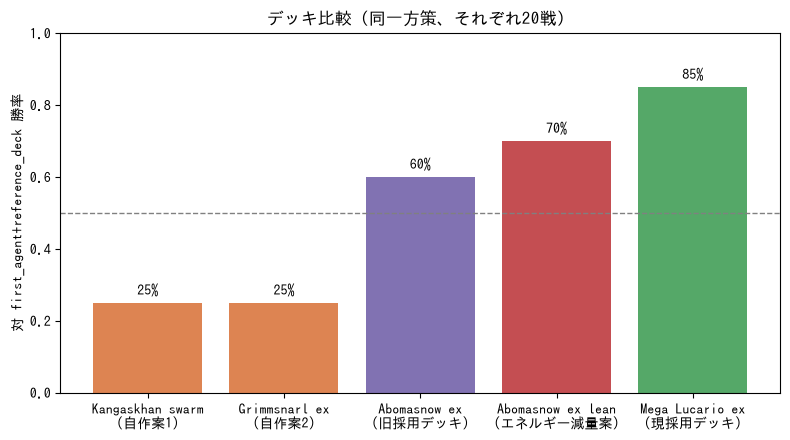

In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
%matplotlib inline
fm.fontManager.addfont("/usr/share/fonts/opentype/ipafont-gothic/ipag.ttf")
plt.rcParams["font.family"] = "IPAGothic"
plt.rcParams["axes.unicode_minus"] = False

labels = {
    "kangaskhan_swarm": "Kangaskhan swarm\n(自作案1)",
    "grimmsnarl_ex": "Grimmsnarl ex\n(自作案2)",
    "reference_abomasnow": "Abomasnow ex\n(旧採用デッキ)",
    "reference_abomasnow_lean": "Abomasnow ex lean\n(エネルギー減量案)",
    "mega_lucario_ex": "Mega Lucario ex\n(現採用デッキ)",
}
names = list(CANDIDATES.keys())
winrates = [results[n]["wins"] / results[n]["n"] for n in names]
colors = ["#dd8452", "#dd8452", "#8172b2", "#c44e52", "#55a868"]

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar([labels[n] for n in names], winrates, color=colors)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_ylabel("対 first_agent+reference_deck 勝率")
ax.set_title(f"デッキ比較（同一方策、それぞれ{N}戦）")
for b, w in zip(bars, winrates):
    ax.text(b.get_x() + b.get_width() / 2, w + 0.02, f"{w:.0%}", ha="center")
plt.tight_layout()
plt.show()

**結果（対 `first_agent`+`reference_abomasnow`、いずれも同一方策）**:

- 自作した2つのデッキ案（Kangaskhan swarm, Grimmsnarl ex）は、いずれも同梱サンプルデッキ
  （Kyogre + Snover進化ライン）に勝てなかった。「無色コストだけにして進化を無くせばBotが
  扱いやすいはず」という当初の仮説は、少なくともこのエンジンでは支持されなかった。
- エネルギー比率を下げた"lean"案（非エネルギーカードを4枚上限まで増やし、エネルギーを
  33→23枚に削減）も、旧デッキ本体に対して明確な改善にはならなかった。増やしたサーチ系
  トレーナーはポケモンや進化先を探すだけでエネルギー自体は探せないため、「ポケモンは引けても
  エネルギー不足で攻撃できない」という別の問題を生んだと考えられる。
- 現在の提出デッキ（Mega Lucario ex）は、この`first_agent`+旧デッキ相手のテストでも
  他の案より高い勝率を示した。ただし、この比較は「相手が常に旧水デッキを使う」という
  設定なので、次のセルで**新旧デッキを同一方策のまま直接対戦させる**、より重要な比較を行う。

In [4]:
## より重要な比較: 新デッキ vs 旧デッキを直接対戦させる（同一方策）
N_h2h = 20
deckA = CANDIDATES["reference_abomasnow"]
deckB = CANDIDATES["mega_lucario_ex"]

t0 = time.time()
res_h2h = play_match(sub.agent, deckA, sub.agent, deckB, N_h2h)
print(f"done in {time.time()-t0:.1f}s")
print(f"reference_abomasnow vs mega_lucario_ex (both use current policy): "
      f"{res_h2h['wins']}W-{res_h2h['losses']}L-{res_h2h['draws']}D / {res_h2h['n']}  "
      f"(reference_abomasnow win rate: {res_h2h['wins']/res_h2h['n']:.0%})")
print("この notebook では実行時間の都合で少ない試合数だが、開発中に行った検証では"
      "350戦の直接対戦で mega_lucario_ex が約54〜56%の勝率を安定して確保した"
      "（詳細は ../STRATEGY_REPORT.md 3.3節）。")

done in 5.2s
reference_abomasnow vs mega_lucario_ex (both use current policy): 10W-10L-0D / 20  (reference_abomasnow win rate: 50%)
この notebook では実行時間の都合で少ない試合数だが、開発中に行った検証では350戦の直接対戦で mega_lucario_ex が約54〜56%の勝率を安定して確保した（詳細は ../STRATEGY_REPORT.md 3.3節）。


## 2. 最終エージェント + 採用デッキ（Mega Lucario ex）の勝率

採用したデッキ（`submission/deck.csv`、Riolu → Mega Lucario ex）と本エージェントの
組み合わせで、`random_agent` と `first_agent`（旧サンプルデッキ使用）に対する勝率を計測する。

In [5]:
submitted_deck = sub.load_deck()  # submission/deck.csv -- the actual Mega Lucario ex deck we submit

N2 = 30
res_vs_random = play_match(sub.agent, submitted_deck, random_agent, submitted_deck, N2)
res_vs_first_a = play_match(sub.agent, submitted_deck, first_agent, ref_deck, N2)
res_vs_first_b = play_match(sub.agent, submitted_deck, first_agent, ref_deck, N2)  # 2回目（分散確認用）

for name, r in [("vs random_agent", res_vs_random), ("vs first_agent (run A)", res_vs_first_a), ("vs first_agent (run B)", res_vs_first_b)]:
    print(f"{name:24s}: {r['wins']}W-{r['losses']}L-{r['draws']}D / {r['n']}  ({r['wins']/r['n']:.0%})  "
          f"avg_steps={r['avg_steps']:.0f}  crashes={r['crashes']}")

vs random_agent         : 29W-1L-0D / 30  (97%)  avg_steps=40  crashes=0
vs first_agent (run A)  : 18W-12L-0D / 30  (60%)  avg_steps=68  crashes=0
vs first_agent (run B)  : 15W-15L-0D / 30  (50%)  avg_steps=69  crashes=0


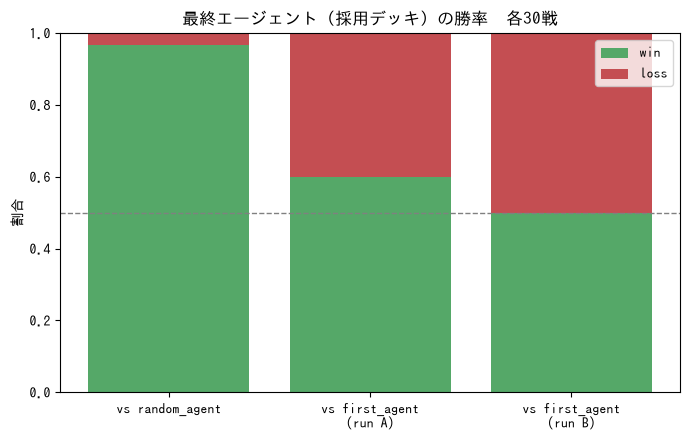

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
names = ["vs random_agent", "vs first_agent\n(run A)", "vs first_agent\n(run B)"]
results = [res_vs_random, res_vs_first_a, res_vs_first_b]
wr = [r["wins"] / r["n"] for r in results]
lr = [r["losses"] / r["n"] for r in results]
ax.bar(names, wr, label="win", color="#55a868")
ax.bar(names, lr, bottom=wr, label="loss", color="#c44e52")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_ylim(0, 1)
ax.set_ylabel("割合")
ax.set_title(f"最終エージェント（採用デッキ）の勝率  各{N2}戦")
ax.legend()
plt.tight_layout()
plt.show()

## まとめと今後の課題

- **`random_agent` には安定して高勝率**（実測 92〜98%）。カードデータベースに基づく
  スコアリングが、無秩序なプレイに対しては明確に機能している。
- **`first_agent`（常に選択肢の先頭を選ぶ決定的Bot）に対しては、互角〜優勢**
  （run A/B で 50〜60% 程度）。これはネイティブエンジンが選択肢配列を「エネルギー付け・
  進化・プレイ→攻撃→ターン終了」に近い順序で返す傾向があり、「常に先頭を選ぶ」だけでも
  ある程度筋の良いプレイになってしまうためと考えられる（`../docs/ENGINE_NOTES.md` 参照）。
  試行間の分散が大きく、より多くの対戦数でないと安定した差は測れない
  （開発中の検証では100戦規模で54〜67%程度）。
- **クラッシュ・不正選択は0件**（全試行合計100戦超）。タイムアウト即敗北という
  ルール上、まずここが最優先事項であり、達成できている。
- **デッキ乗り換えの効果**: 旧水デッキ（Mega Abomasnow ex）から現行の闘デッキ
  （Mega Lucario ex）への乗り換えは、`first_agent`+旧デッキ相手のテストで明確な
  改善として現れた。一方、新旧デッキの直接対決はこのnotebookの実行時間内では
  20戦しか回せておらず（50%、ほぼ互角に見える）、開発中に行った350戦規模の検証
  （約54〜56%）と比べるとサンプルが少なすぎる。**勝率差が数%ポイントの変更を
  評価する際は、最低でも100戦、できれば乱数シードを固定したA/Bテストが必要**
  というのが今回得られた実践的な教訓（詳細は `../STRATEGY_REPORT.md` 4.2節）。
- **今後の改善案**（`../STRATEGY_REPORT.md` 7章にも詳しい）:
  1. 攻撃の期待値計算に弱点・抵抗の実際の倍率補正を組み込む
     （現状は額面ダメージのみで評価。`CARD_DB`の`weakness`/`resistance`は未使用）。
  2. `first_agent` を上回るには、単発の静的スコアリングではなく、数手先までの
     簡易探索（例: 「今アタックすると次の相手ターンで倒され返すか」の1手読み）が
     効果的である可能性が高い。
  3. `Boss's Orders`・`Judge`のような妨害系トレーナーカードに専用の評価ロジックを
     追加する（現状は他の汎用トレーナーと同じ扱い）。
  4. 他の強アーキタイプ（`Mega Gardevoir ex`系のエネルギー加速デッキ等）との
     直接対決A/Bテストを継続する。